In [ ]:
# ==========================================
# Celda 1: Setup e imports
# ==========================================
import os
import json
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore", category=UserWarning)
tf.get_logger().setLevel("ERROR")

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


In [ ]:
# ==========================================
# Celda 2: (Opcional) montar Google Drive
# ==========================================
# Si tu CSV está en Drive, descomentá estas líneas:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# ==========================================
# Celda 3: Configuración
# ==========================================
# Ajustá DATA_PATH según dónde esté tu archivo
# Ejemplo local en Colab: "/content/completo.csv"
# Ejemplo en Drive: "/content/drive/MyDrive/TP/completo.csv"

DATA_PATH = "/content/completo.csv"

DATE_COL = "Semana"
TARGET_COL = "Cortes"
FEATURE_COLS = ["Cortes", "Temp", "Hum"]  # mínimos cambios (target + exógenas)

HORIZONS = [1, 2, 3]      # 1,2,3 semanas adelante
WINDOW_SIZE = 8           # lookback / cantidad de lags
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

# Hiperparámetros base (fiel al enfoque cátedra, sin grid)
RNN_UNITS = 40
DROPOUT = 0.20
LEARNING_RATE = 1e-3
BATCH_SIZE = 16
EPOCHS = 200
PATIENCE = 15

SEED = 42
MAPE_EPS = 1e-8

np.random.seed(SEED)
tf.random.set_seed(SEED)

os.makedirs("outputs/metrics", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/models", exist_ok=True)

print("Configuración OK")


Configuración OK


In [ ]:
# ==========================================
# Celda 4: Helpers
# ==========================================
def to_float_comma(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(",", ".", regex=False).str.strip(),
        errors="coerce"
    )

def temporal_split(df, train_ratio=0.70, val_ratio=0.15):
    n = len(df)
    i_train = int(n * train_ratio)
    i_val = int(n * (train_ratio + val_ratio))
    return df.iloc[:i_train].copy(), df.iloc[i_train:i_val].copy(), df.iloc[i_val:].copy()

def create_sequences(X, y, window_size, horizon):
    """
    X: [n_samples, n_features]
    y: [n_samples]
    returns:
      Xs: [n_seq, window_size, n_features]
      ys: [n_seq]
    """
    Xs, ys = [], []
    for i in range(len(X) - window_size - horizon + 1):
        Xs.append(X[i:i + window_size])
        ys.append(y[i + window_size + horizon - 1])
    return np.array(Xs), np.array(ys)

def build_model(input_shape, rnn_units=40, dropout=0.2, learning_rate=1e-3):
    # secuencia -> capa recurrente -> salida Dense(1)
    # Adaptación mínima: LSTM en lugar de SimpleRNN
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(rnn_units, return_sequences=False),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(1)
    ])

    model.compile(
        loss="mse",
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
    )
    return model

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape_safe(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.maximum(np.abs(y_true), eps)
    return float(100.0 * np.mean(np.abs((y_true - y_pred) / denom)))

def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred) + eps
    return float(100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / denom))

print("Helpers OK")


Helpers OK


In [ ]:
# ==========================================
# Celda 5: Carga y limpieza
# ==========================================
df = pd.read_csv(DATA_PATH)

# Parse fecha
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")

# Conversión numérica robusta (incluye coma decimal)
df["Cortes"] = pd.to_numeric(df["Cortes"], errors="coerce")
df["Temp"] = to_float_comma(df["Temp"])
df["Hum"] = to_float_comma(df["Hum"])

# Orden temporal y limpieza básica
df = df.dropna(subset=[DATE_COL]).sort_values(DATE_COL).reset_index(drop=True)
df = df[[DATE_COL, TARGET_COL, "Temp", "Hum"]]
df = df.interpolate(method="linear").ffill().bfill()

print("Rango temporal:", df[DATE_COL].min(), "->", df[DATE_COL].max())
print("Observaciones:", len(df))
display(df.head(10))


Rango temporal: 2020-12-06 00:00:00 -> 2025-12-07 00:00:00
Observaciones: 262


,Semana,Cortes,Temp,Hum
0,2020-12-06,17,20.735714,62.532857
1,2020-12-13,23,24.490000,49.370000
2,2020-12-20,22,23.690000,51.560000
3,2020-12-27,37,27.928571,48.910000
4,2021-01-03,27,27.341429,39.745714
5,2021-01-10,24,26.550000,50.440000
6,2021-01-17,22,23.351429,59.438571
7,2021-01-24,33,28.304286,55.111429
8,2021-01-31,25,24.162857,75.755714
9,2021-02-07,24,23.134286,63.818571


In [ ]:
# ==========================================
# Celda 6: Split + escalado
# ==========================================
train_df, val_df, test_df = temporal_split(df, TRAIN_RATIO, VAL_RATIO)
print(f"Split -> Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# Matrices crudas
X_train_raw = train_df[FEATURE_COLS].values
y_train_raw = train_df[TARGET_COL].values

X_val_raw = val_df[FEATURE_COLS].values
y_val_raw = val_df[TARGET_COL].values

X_test_raw = test_df[FEATURE_COLS].values
y_test_raw = test_df[TARGET_COL].values

# Escalado (fit SOLO en train)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train_raw)
X_val_scaled = scaler_X.transform(X_val_raw)
X_test_scaled = scaler_X.transform(X_test_raw)

y_train_scaled = scaler_y.fit_transform(y_train_raw.reshape(-1, 1)).ravel()
y_val_scaled = scaler_y.transform(y_val_raw.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test_raw.reshape(-1, 1)).ravel()

print("Escalado OK")
print("X_train_scaled:", X_train_scaled.shape, "| y_train_scaled:", y_train_scaled.shape)


Split -> Train: 183 | Val: 39 | Test: 40
Escalado OK
X_train_scaled: (183, 3) | y_train_scaled: (183,)



===== Horizonte h=1 =====
Secuencias -> train:(175, 8, 3), val:(31, 8, 3), test:(32, 8, 3)
VAL  -> RMSE=7.9298 MAE=6.1555 MAPE=25.20% sMAPE=23.74%
TEST -> RMSE=6.8234 MAE=4.6205 MAPE=18.62% sMAPE=18.98%


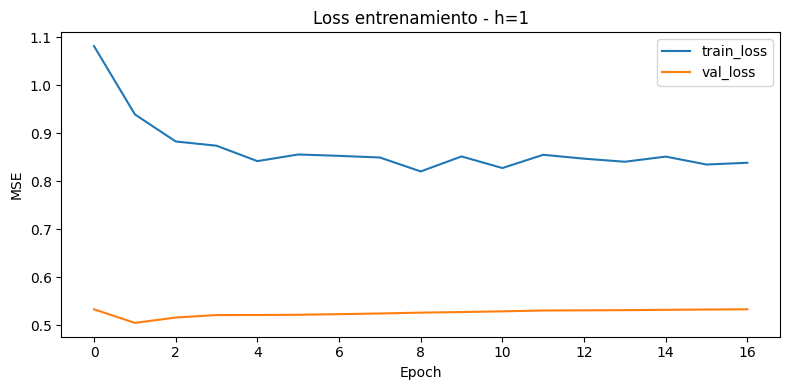

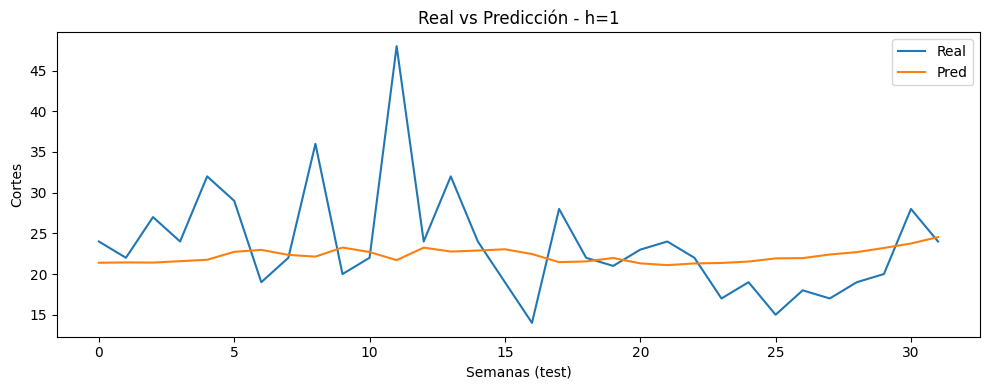


===== Horizonte h=2 =====
Secuencias -> train:(174, 8, 3), val:(30, 8, 3), test:(31, 8, 3)
VAL  -> RMSE=7.9047 MAE=6.0003 MAPE=24.37% sMAPE=23.18%
TEST -> RMSE=7.5267 MAE=5.1503 MAPE=20.02% sMAPE=21.36%


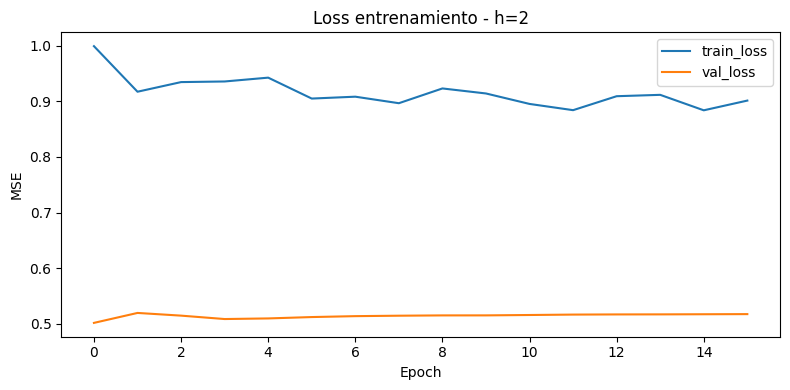

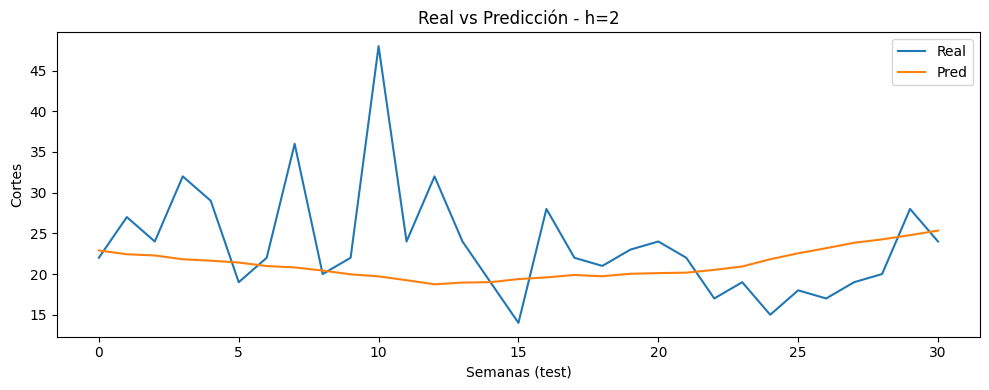


===== Horizonte h=3 =====
Secuencias -> train:(173, 8, 3), val:(29, 8, 3), test:(30, 8, 3)
VAL  -> RMSE=7.8839 MAE=5.8502 MAPE=23.13% sMAPE=22.45%
TEST -> RMSE=6.9708 MAE=4.6846 MAPE=18.51% sMAPE=19.14%


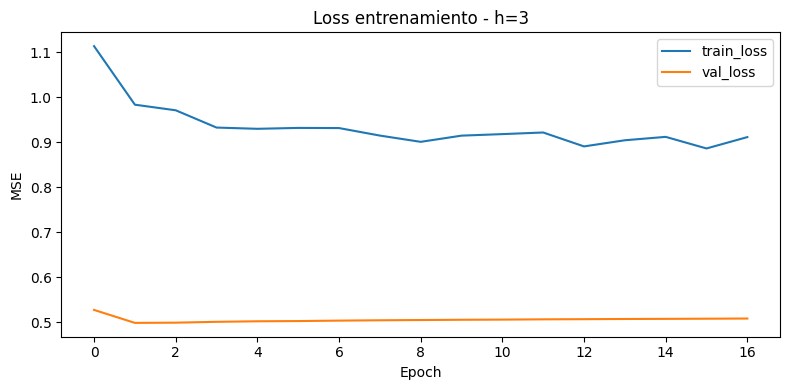

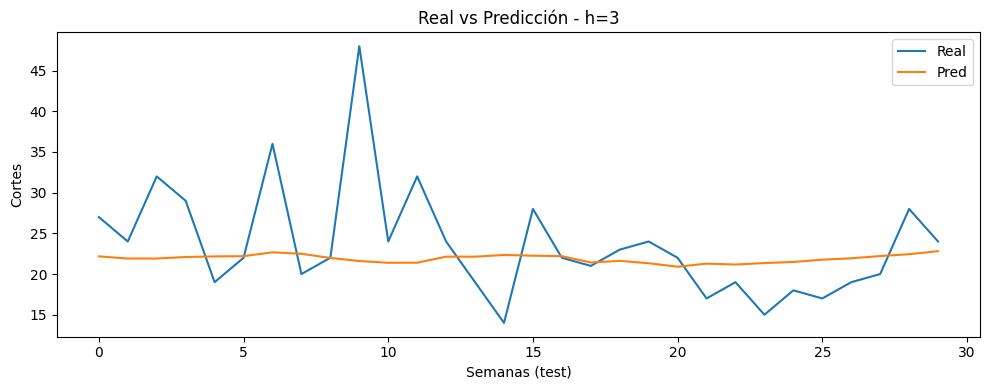

In [ ]:
# ==========================================
# Celda 7: Entrenamiento por horizonte
# ==========================================
results_by_h = []

for horizon in HORIZONS:
    print(f"\n===== Horizonte h={horizon} =====")

    # Secuencias (ventanas)
    X_train, y_train = create_sequences(X_train_scaled, y_train_scaled, WINDOW_SIZE, horizon)
    X_val, y_val = create_sequences(X_val_scaled, y_val_scaled, WINDOW_SIZE, horizon)
    X_test, y_test = create_sequences(X_test_scaled, y_test_scaled, WINDOW_SIZE, horizon)

    if len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0:
        print(f"[WARN] Sin secuencias para h={horizon}")
        continue

    print(
        f"Secuencias -> train:{X_train.shape}, val:{X_val.shape}, test:{X_test.shape}"
    )

    model = build_model(
        input_shape=(X_train.shape[1], X_train.shape[2]),
        rnn_units=RNN_UNITS,
        dropout=DROPOUT,
        learning_rate=LEARNING_RATE
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-6
        )
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0,
        callbacks=callbacks
    )

    # Validación en escala real
    pred_val_scaled = model.predict(X_val, verbose=0).ravel()
    y_val_real = scaler_y.inverse_transform(y_val.reshape(-1, 1)).ravel()
    y_val_pred_real = scaler_y.inverse_transform(pred_val_scaled.reshape(-1, 1)).ravel()

    val_rmse = rmse(y_val_real, y_val_pred_real)
    val_mae = float(mean_absolute_error(y_val_real, y_val_pred_real))
    val_mape = mape_safe(y_val_real, y_val_pred_real, eps=MAPE_EPS)
    val_smape = smape(y_val_real, y_val_pred_real, eps=MAPE_EPS)

    # Test en escala real
    pred_test_scaled = model.predict(X_test, verbose=0).ravel()
    y_test_real = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()
    y_test_pred_real = scaler_y.inverse_transform(pred_test_scaled.reshape(-1, 1)).ravel()

    test_rmse = rmse(y_test_real, y_test_pred_real)
    test_mae = float(mean_absolute_error(y_test_real, y_test_pred_real))
    test_mape = mape_safe(y_test_real, y_test_pred_real, eps=MAPE_EPS)
    test_smape = smape(y_test_real, y_test_pred_real, eps=MAPE_EPS)

    print(
        f"VAL  -> RMSE={val_rmse:.4f} MAE={val_mae:.4f} MAPE={val_mape:.2f}% sMAPE={val_smape:.2f}%"
    )
    print(
        f"TEST -> RMSE={test_rmse:.4f} MAE={test_mae:.4f} MAPE={test_mape:.2f}% sMAPE={test_smape:.2f}%"
    )

    # Guardado de modelo
    model_path = f"outputs/models/lstm_h{horizon}.keras"
    model.save(model_path)

    # Figura loss
    plt.figure(figsize=(8, 4))
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.title(f"Loss entrenamiento - h={horizon}")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"outputs/figures/loss_h{horizon}.png", dpi=140)
    plt.show()
    plt.close()

    # Figura real vs pred
    plt.figure(figsize=(10, 4))
    plt.plot(y_test_real, label="Real")
    plt.plot(y_test_pred_real, label="Pred")
    plt.title(f"Real vs Predicción - h={horizon}")
    plt.xlabel("Semanas (test)")
    plt.ylabel(TARGET_COL)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"outputs/figures/real_vs_pred_h{horizon}.png", dpi=140)
    plt.show()
    plt.close()

    results_by_h.append({
        "horizon": horizon,
        "window_size": WINDOW_SIZE,
        "rnn_units": RNN_UNITS,
        "dropout": DROPOUT,
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "epochs_max": EPOCHS,
        "n_train_seq": int(len(y_train)),
        "n_val_seq": int(len(y_val)),
        "n_test_seq": int(len(y_test)),
        "val_rmse": val_rmse,
        "val_mae": val_mae,
        "val_mape": val_mape,
        "val_smape": val_smape,
        "rmse_test": test_rmse,
        "mae_test": test_mae,
        "mape_test": test_mape,
        "smape_test": test_smape,
        "model_path": model_path
    })


In [ ]:
# ==========================================
# Celda 8: Export de métricas + resumen
# ==========================================
if results_by_h:
    df_results = pd.DataFrame(results_by_h).sort_values("horizon")
    csv_path = "outputs/metrics/rnn_tp2_by_h.csv"
    json_path = "outputs/metrics/rnn_tp2_by_h.json"

    df_results.to_csv(csv_path, index=False)
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(results_by_h, f, ensure_ascii=False, indent=2)

    print("Resumen por horizonte:")
    display(df_results[[
        "horizon", "window_size", "rnn_units", "dropout", "learning_rate",
        "val_rmse", "val_mae", "val_mape",
        "rmse_test", "mae_test", "mape_test", "smape_test",
        "n_train_seq", "n_val_seq", "n_test_seq", "model_path"
    ]])

    print("\nArchivos generados:")
    print("CSV :", csv_path)
    print("JSON:", json_path)
else:
    print("No hubo resultados. Revisar configuración/datos.")


Resumen por horizonte:


,horizon,window_size,rnn_units,dropout,learning_rate,val_rmse,val_mae,val_mape,rmse_test,mae_test,mape_test,smape_test,n_train_seq,n_val_seq,n_test_seq,model_path
0,1,8,40,0.2,0.001,7.929838,6.155503,25.202592,6.823361,4.620478,18.622819,18.975829,175,31,32,outputs/models/lstm_h1.keras
1,2,8,40,0.2,0.001,7.904709,6.000349,24.372994,7.526737,5.150260,20.024642,21.360072,174,30,31,outputs/models/lstm_h2.keras
2,3,8,40,0.2,0.001,7.883876,5.850152,23.128984,6.970780,4.684625,18.505483,19.140005,173,29,30,outputs/models/lstm_h3.keras



Archivos generados:
CSV : outputs/metrics/rnn_tp2_by_h.csv
JSON: outputs/metrics/rnn_tp2_by_h.json


In [ ]:
# ==========================================
# Celda 9: (Opcional) comprimir outputs
# ==========================================
!zip -r outputs.zip outputs >/dev/null 2>&1
print("ZIP generado: outputs.zip")


ZIP generado: outputs.zip


In [ ]:
# ==========================================
# Celda 10: (Opcional) descarga local en Colab
# ==========================================
# from google.colab import files
# files.download("outputs.zip")
